# Homework Assignment 3. Logistic Regression

Consider data in `HousingData.csv`. The Boston Housing Dataset is derived from information collected by the U.S. Census Service concerning housing in the area of Boston MA.

| Column | Description |
|---|---|
| `CRIM` | Per capita crime rate by town |
| `ZN` | Proportion of residential land zoned for lots over 25,000 sq.ft. |
| `INDUS` | Proportion of non-retail business acres per town |
| `CHAS` | Charles River dummy variable (1 if tract bounds river; 0 otherwise) |
| `NOX` | Nitric oxides concentration (parts per 10 million) |
| `RM` | Average number of rooms per dwelling |
| `AGE` | Proportion of owner-occupied units built prior to 1940 |
| `DIS` | Weighted distances to five Boston employment centres |
| `RAD` | Index of accessibility to radial highways |
| `TAX` | Full-value property-tax rate per $10,000 |
| `PTRATIO` | Pupil-teacher ratio by town |
| `B` | $1000(B_k - 0.63)^2$ where $B_k$ is the proportion of blacks by town |
| `LSTAT` | Lower status of the population |
| `MEDV` | Median value of owner-occupied homes in $1000's |

Introduce new variable **ET** (*expensive town*) equal to **1** if $MEDV > 20$ and **0** otherwise, indicating high median value of owner-occupied homes.

## Task 1 (0.4 pt.) — Linear Probability Model

Run and analyze a **linear probability model** for `ET` on `CRIM`, `CHAS`, `RM`, `AGE`, `DIS`, `RAD`, `TAX`, `PTRATIO`, `LSTAT`. Explain what are possible drawbacks of this approach.

In [1]:
# import modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import statsmodels.api as sm

In [2]:
df = pd.read_csv('data/data.csv')

In [3]:
# Linear Probability Model
predictors = ['CRIM', 'CHAS', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT']
df['ET'] = (df['MEDV'] > 20).astype(int)
df = df.dropna(subset=predictors + ['ET']).copy()

X = sm.add_constant(df[predictors])
y = df['ET']

lpm = sm.OLS(y, X).fit()
print(lpm.summary())

pred = lpm.predict(X)
print(f'Predicted values in [0,1]: {((pred >= 0) & (pred <= 1)).mean():.3f}')

                            OLS Regression Results                            
Dep. Variable:                     ET   R-squared:                       0.579
Model:                            OLS   Adj. R-squared:                  0.570
Method:                 Least Squares   F-statistic:                     63.98
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           4.29e-73
Time:                        14:18:48   Log-Likelihood:                -121.33
No. Observations:                 428   AIC:                             262.7
Df Residuals:                     418   BIC:                             303.2
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3170      0.307      7.547      0.0

## Task 2 (0.4 pt.) — Logistic Regression

Run a **logistic regression** for variable `ET` on `CRIM`, `CHAS`, `RM`, `AGE`, `DIS`, `RAD`, `TAX`, `PTRATIO`, `LSTAT`. Explain in your own words how the logistic model is constructed. Present the obtained outcome.

In [4]:
# Logistic Regression
logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.257278
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                     ET   No. Observations:                  428
Model:                          Logit   Df Residuals:                      418
Method:                           MLE   Df Model:                            9
Date:                Mon, 09 Mar 2026   Pseudo R-squ.:                  0.6238
Time:                        14:18:50   Log-Likelihood:                -110.12
converged:                       True   LL-Null:                       -292.72
Covariance Type:            nonrobust   LLR p-value:                 3.561e-73
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.6041      3.426      2.803      0.005       2.889      16.320
CRIM          -0.2458      0.

## Task 3 (0.4 pt.) — Interpretation of Coefficients

How can we interpret the obtained estimates of coefficients? Choose one independent variable and provide the correct interpretation of its parameter using **odds**.

## Task 4 (0.4 pt.) — Effect of Variables on Probability

Discuss what variables **increase** the probability for $MEDV > 20$ ($ET = 1$) and what **decrease** it. Do these results coincide with your intuition?

## Task 5 (0.4 pt.) — Goodness of Fit

Discuss the **goodness of fit** of the model.

## Task 6 (0.4 pt.) — Predicted Probabilities

Choose **5 different observations** and, using the estimated model, compute for them the **predicted probability** for $ET = 1$. Provide the formula that should be used:

$$\hat{P}(ET=1) = \frac{1}{1 + e^{-(\hat{\beta}_0 + \hat{\beta}_1 x_1 + \cdots + \hat{\beta}_k x_k)}}$$

In [12]:
# Predicted probabilities for 5 observations
sample = df.sample(5, random_state=42)
X_sample = sm.add_constant(sample[predictors], has_constant='add')

probs = logit_model.predict(X_sample)

result = sample[predictors + ['ET', 'MEDV']].copy()
result['P(ET=1)'] = probs.values
print(result[['MEDV', 'ET', 'P(ET=1)']].to_string())

     MEDV  ET   P(ET=1)
496  19.7   0  0.033125
85   26.6   1  0.980009
204  50.0   1  0.999911
34   13.5   0  0.012318
425   8.3   0  0.001065


## Task 7 (0.4 pt.) — Classification of 5 Observations

If you want to predict whether the observed town has a high $MEDV$ ($> 20$), what is the simplest way to do this using the logistic model? **Compare** the results obtained in this way with the true values for the considered 5 observations.

In [ ]:
# Classify the 5 sampled observations using threshold 0.5
result['ET_pred'] = (r  esult['P(ET=1)'] >= 0.5).astype(int)
print(result[['MEDV', 'ET', 'P(ET=1)', 'ET_pred']].to_string())

     MEDV  ET   P(ET=1)  ET_pred
496  19.7   0  0.033125        0
85   26.6   1  0.980009        1
204  50.0   1  0.999911        1
34   13.5   0  0.012318        0
425   8.3   0  0.001065        0


## Task 8 (0.4 pt.) — Confusion Matrix

Apply this approach to classify **all observations** and construct the corresponding **confusion matrix**. Compute **accuracy**, **sensitivity**, and **specificity**. Explain what these values show.

Accuracy:    0.900
Sensitivity: 0.918
Specificity: 0.876


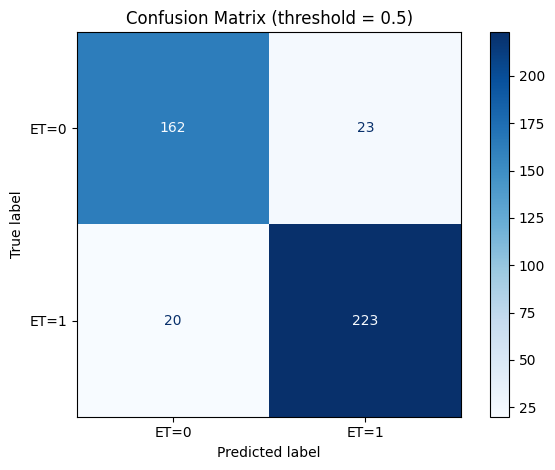

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_probs = logit_model.predict(X)
y_pred = (all_probs >= 0.5).astype(int)

cm = confusion_matrix(y, y_pred)
tn, fp, fn, tp = cm.ravel()

accuracy    = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)   # recall / true positive rate
specificity = tn / (tn + fp)   # true negative rate

print(f'Accuracy:    {accuracy:.3f}')
print(f'Sensitivity: {sensitivity:.3f}')
print(f'Specificity: {specificity:.3f}')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ET=0', 'ET=1'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (threshold = 0.5)')
plt.tight_layout()
plt.show()

## Task 9 (0.4 pt.) — ROC Curve & Optimal Threshold

Explain in your own words what a **ROC curve** is. Using it, choose the **optimal threshold** to classify observations — how to do it? For the new threshold, construct a new confusion matrix and compute **accuracy**, **sensitivity**, and **specificity**. Are your new results better? Why?

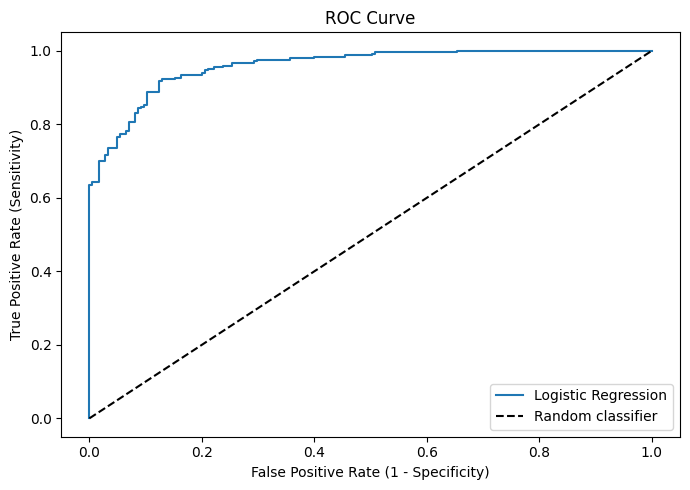

Optimal threshold (Youden's J): 0.501


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y, all_probs)

# Plot ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

# Optimal threshold: maximise Youden's J = sensitivity + specificity - 1
j_scores = tpr - fpr
optimal_idx = j_scores.argmax()
optimal_threshold = thresholds[optimal_idx]
print(f'Optimal threshold: {optimal_threshold:.3f}')

## Task 10 (0.4 pt.) — AUC

Compute the **AUC** (Area Under the Curve). What does it show? Explain in your own words how to use it.

In [16]:
auc = roc_auc_score(y, all_probs)
print(f'AUC: {auc:.3f}')

AUC: 0.958
